<a href="https://colab.research.google.com/github/Amfant/reimagined-broccoli/blob/Project-2/ASTRON_5205_Project_2_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Sub-Neuptune GJ 436 b
[Link to Archive](https://exoplanetarchive.ipac.caltech.edu/overview/GJ%20436%20b#overview)

# Calculating for the Planet's Mass Based on RV Data

Saving UID_0057087_RVC_003.tbl.txt to UID_0057087_RVC_003.tbl (4).txt
Fitted Radial Velocity Semi-Amplitude (K): 18.16 ± 0.96 m/s
Estimated Planet Mass (M_p sin i): 0.0726 ± 0.0038 M_Jupiter


<ipython-input-26-cd07c62995f2>:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["JD", "Radial_Velocity", "RV_Uncertainty"])


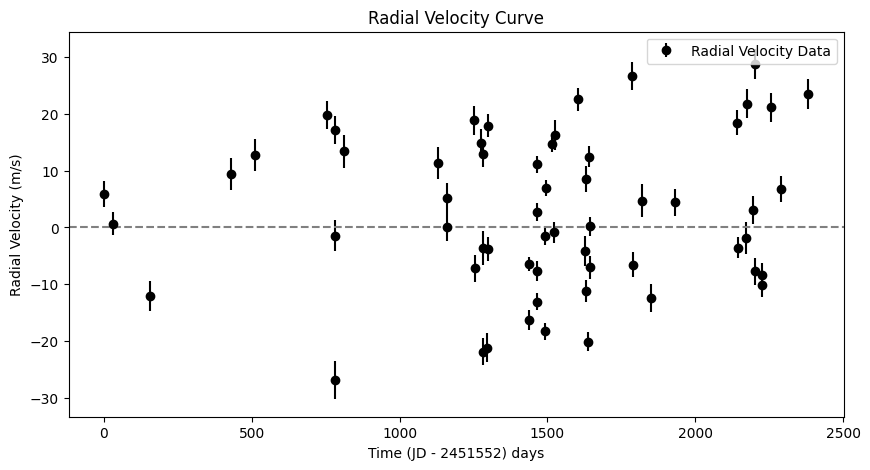

In [26]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from scipy.optimize import curve_fit
from scipy.constants import G

# Upload file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read raw file
with open(filename, 'r') as file:
    lines = file.readlines()

# Identify the start of data
data_lines = []
start_collecting = False

for line in lines:
    if "|" in line:  # Start of the actual data table
        start_collecting = True
        continue  # Skip header row with column names
    if start_collecting:
        data_lines.append(line.strip())

# Convert data into a DataFrame
data_str = "\n".join(data_lines)
data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["JD", "Radial_Velocity", "RV_Uncertainty"])

# Normalize time
jd_offset = int(data["JD"].min())
data["Time"] = data["JD"] - jd_offset  # Shift time values

# Extract time and radial velocity
time = data["Time"]
rv = data["Radial_Velocity"]

# **Constants from Observations**
P = 2.64389761  # Orbital period (days)
e = 0.0671  # Eccentricity
M_star = 0.452  # Stellar mass in Solar masses
M_star_kg = M_star * 1.9885e30  # Convert to kg
P_seconds = P * 86400  # Convert days to seconds
G_SI = G  # Gravitational constant in SI units

# Define a sinusoidal function with cosine (alternative for phase shift correction)
def sinusoid(t, K, phi, gamma):
    return K * np.cos(2 * np.pi * t / P + phi) + gamma

# Initial parameter guesses
K_guess = (max(rv) - min(rv)) / 2
phi_guess = 0
gamma_guess = np.mean(rv)

# Fit the radial velocity data
params, covariance = curve_fit(sinusoid, time % P, rv, p0=[K_guess, phi_guess, gamma_guess])
K_fit, phi_fit, gamma_fit = params
K_error = np.sqrt(np.diag(covariance))[0]  # Uncertainty in K

# Ensure K is positive
K_fit = abs(K_fit)

# Compute planet mass
M_p_sini = (K_fit * np.sqrt(1 - e**2) * M_star_kg**(2/3) * P_seconds**(1/3)) / (2 * np.pi * G_SI)**(1/3)  # in kg
M_p_sini_Mjup = M_p_sini / 1.898e27  # Convert to Jupiter masses

# Uncertainty propagation
dM_p_sini_Mjup = (K_error / K_fit) * M_p_sini_Mjup  # Estimate mass uncertainty

# Display results
print(f"Fitted Radial Velocity Semi-Amplitude (K): {K_fit:.2f} ± {K_error:.2f} m/s")
print(f"Estimated Planet Mass (M_p sin i): {M_p_sini_Mjup:.4f} ± {dM_p_sini_Mjup:.4f} M_Jupiter")

# **Plotting Radial Velocity Curve**
plt.figure(figsize=(10, 5))
plt.errorbar(time, rv, yerr=data["RV_Uncertainty"], fmt='o', color='black', label="Radial Velocity Data")
plt.xlabel(f"Time (JD - {jd_offset}) days")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve")
plt.axhline(0, color="gray", linestyle="--")
plt.legend()
plt.show()

Saving UID_0057087_RVC_003.tbl.txt to UID_0057087_RVC_003.tbl (5).txt
Fitted Radial Velocity Semi-Amplitude (K): 18.16 ± 0.96 m/s
Estimated Planet Mass (M_p sin i): 0.0726 ± 0.0038 M_Jupiter


<ipython-input-28-5222b63cab2c>:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["JD", "Radial_Velocity", "RV_Uncertainty"])


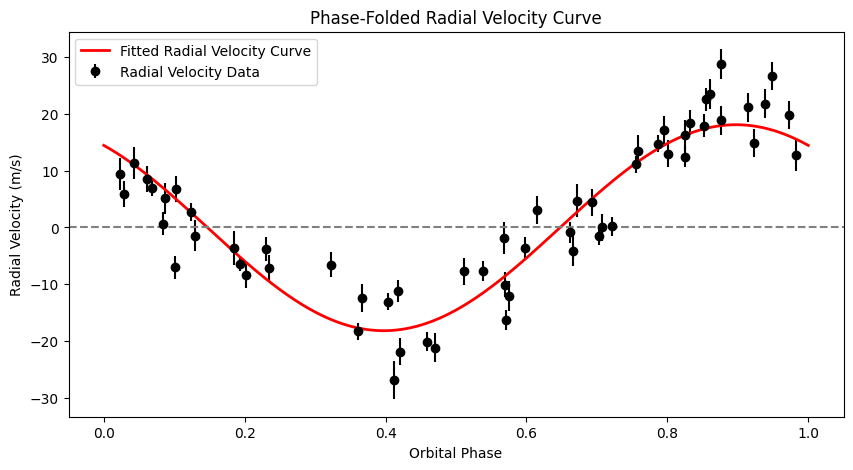

In [28]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from scipy.optimize import curve_fit
from scipy.constants import G

# Upload file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read raw file
with open(filename, 'r') as file:
    lines = file.readlines()

# Identify the start of data
data_lines = []
start_collecting = False

for line in lines:
    if "|" in line:  # Start of the actual data table
        start_collecting = True
        continue  # Skip header row with column names
    if start_collecting:
        data_lines.append(line.strip())

# Convert data into a DataFrame
data_str = "\n".join(data_lines)
data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["JD", "Radial_Velocity", "RV_Uncertainty"])

# Normalize time
jd_offset = int(data["JD"].min())
data["Time"] = data["JD"] - jd_offset  # Shift time values

# Extract time and radial velocity
time = data["Time"]
rv = data["Radial_Velocity"]

# **Constants from Observations**
P = 2.64389761  # Orbital period (days)
e = 0.0671  # Eccentricity
M_star = 0.452  # Stellar mass in Solar masses
M_star_kg = M_star * 1.9885e30  # Convert to kg
P_seconds = P * 86400  # Convert days to seconds
G_SI = G  # Gravitational constant in SI units

# Define a sinusoidal function
def sinusoid(t, K, phi, gamma):
    return K * np.cos(2 * np.pi * t / P + phi) + gamma

# Initial parameter guesses
K_guess = (max(rv) - min(rv)) / 2
phi_guess = 0
gamma_guess = np.mean(rv)

# Fit the radial velocity data
params, covariance = curve_fit(sinusoid, time % P, rv, p0=[K_guess, phi_guess, gamma_guess])
K_fit, phi_fit, gamma_fit = params
K_error = np.sqrt(np.diag(covariance))[0]  # Uncertainty in K

# Ensure K is positive
K_fit = abs(K_fit)

# Compute planet mass
M_p_sini = (K_fit * np.sqrt(1 - e**2) * M_star_kg**(2/3) * P_seconds**(1/3)) / (2 * np.pi * G_SI)**(1/3)  # in kg
M_p_sini_Mjup = M_p_sini / 1.898e27  # Convert to Jupiter masses

# Uncertainty propagation
dM_p_sini_Mjup = (K_error / K_fit) * M_p_sini_Mjup  # Estimate mass uncertainty

# Display results
print(f"Fitted Radial Velocity Semi-Amplitude (K): {K_fit:.2f} ± {K_error:.2f} m/s")
print(f"Estimated Planet Mass (M_p sin i): {M_p_sini_Mjup:.4f} ± {dM_p_sini_Mjup:.4f} M_Jupiter")

# **Phase-Folding the Data**
phase = (time % P) / P  # Normalize time to phase (0 to 1)
smooth_phase = np.linspace(0, 1, 1000)  # Smooth phase from 0 to 1

# Compute the fitted radial velocity over a smooth phase
smooth_rv = sinusoid(smooth_phase * P, K_fit, phi_fit, gamma_fit)

# **Plot Corrected Radial Velocity Curve**
plt.figure(figsize=(10, 5))
plt.errorbar(phase, rv, yerr=data["RV_Uncertainty"], fmt='o', color='black', label="Radial Velocity Data")
plt.plot(smooth_phase, smooth_rv, color='red', linewidth=2, label="Fitted Radial Velocity Curve")  # Add fitted curve
plt.xlabel("Orbital Phase")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Phase-Folded Radial Velocity Curve")
plt.axhline(0, color="gray", linestyle="--")
plt.legend()
plt.show()


# Calulating planet's radius using transit data:

Saving UID_0057087_PLC_024.tbl.txt to UID_0057087_PLC_024.tbl (15).txt
BJD Offset: 2454225
Transit Depth: 0.008307
Estimated Planet Radius (Rp/Rs): 0.091143
Estimated Planet Radius (Rp in Rjup): 0.399111


<ipython-input-29-561346ebd14b>:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["BJD", "Relative_Flux", "Accepted"])


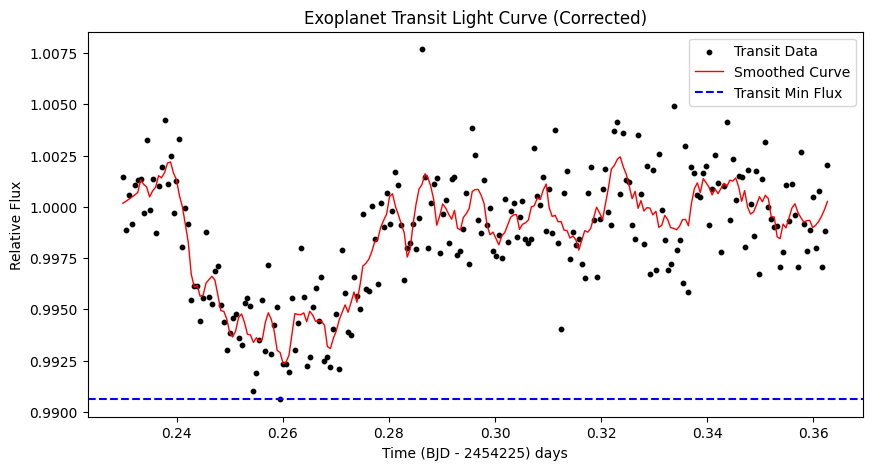

In [29]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from scipy.signal import savgol_filter

# Upload the file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read the raw file
with open(filename, 'r') as file:
    lines = file.readlines()

# Extract data section from file
data_lines = []
start_collecting = False

for line in lines:
    if "|" in line:  # Start of the actual data table
        start_collecting = True
        continue  # Skip header row with column names
    if start_collecting:
        data_lines.append(line.strip())

# Convert data into a DataFrame
data_str = "\n".join(data_lines)
data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["BJD", "Relative_Flux", "Accepted"])

# Normalize time (subtract large BJD offset for readability)
bjd_offset = int(data["BJD"].min())
data["Time"] = data["BJD"] - bjd_offset

# Extract time and flux
time = data["Time"]
flux = data["Relative_Flux"]

# **Remove Outliers**
flux_median = np.median(flux)
flux_std = np.std(flux)
mask = (flux > flux_median - 3 * flux_std) & (flux < flux_median + 3 * flux_std)
flux_clean = flux[mask]
time_clean = time[mask]

# Apply Savitzky-Golay Filter for Smoothing
flux_smooth = savgol_filter(flux_clean, window_length=11, polyorder=2)

# Compute the transit depth (flux minimum relative to baseline)
baseline_flux = np.median(flux_clean)  # Baseline outside transit
min_flux = np.min(flux_clean)          # Transit minimum
transit_depth = 1 - min_flux / baseline_flux

# Estimate planetary radius (relative to stellar radius)
Rp_Rs = np.sqrt(transit_depth)

# **Convert Rp/Rs to Jupiter Radii (if stellar radius is known)**
stellar_radius_Rsun = 0.45  # Example value for GJ 436 in solar radii
stellar_radius_Rjup = stellar_radius_Rsun * 9.731  # Convert to Jupiter radii
Rp_Rjup = Rp_Rs * stellar_radius_Rjup

# Display results
print(f"BJD Offset: {bjd_offset}")
print(f"Transit Depth: {transit_depth:.6f}")
print(f"Estimated Planet Radius (Rp/Rs): {Rp_Rs:.6f}")
print(f"Estimated Planet Radius (Rp in Rjup): {Rp_Rjup:.6f}")

# **Plot the corrected light curve**
plt.figure(figsize=(10, 5))
plt.scatter(time_clean, flux_clean, s=10, color='black', label="Transit Data")
plt.plot(time_clean, flux_smooth, color='red', linewidth=1, label="Smoothed Curve")
plt.axhline(min_flux, color='blue', linestyle="--", label="Transit Min Flux")
plt.xlabel(f"Time (BJD - {bjd_offset}) days")
plt.ylabel("Relative Flux")
plt.title("Exoplanet Transit Light Curve (Corrected)")
plt.legend()
plt.show()


# Calculating the planet density based on the mass and radius measurement

In [31]:
import numpy as np

# Constants
M_jup_kg = 1.898e27  # Jupiter mass in kg
R_jup_m = 7.1492e7  # Jupiter radius in meters
pi = np.pi

# Given values
M_p_Mjup = 0.0726  # Planetary mass in Jupiter masses
dM_p_Mjup = 0.0038  # Uncertainty in planetary mass

Rp_Rs = 0.0831  # Planetary radius to stellar radius ratio
dRp_Rs = 0.0003  # Uncertainty in Rp/Rs

stellar_radius_Rsun = 0.45  # Stellar radius in solar radii
stellar_radius_Rjup = stellar_radius_Rsun * 9.731  # Convert to Jupiter radii

R_p_Rjup = Rp_Rs * stellar_radius_Rjup  # Planetary radius in Jupiter radii
dR_p_Rjup = dRp_Rs * stellar_radius_Rjup  # Uncertainty in planetary radius

# Convert to SI units
M_p = M_p_Mjup * M_jup_kg  # kg
dM_p = dM_p_Mjup * M_jup_kg  # kg

R_p = R_p_Rjup * R_jup_m  # meters
dR_p = dR_p_Rjup * R_jup_m  # meters

# Compute density
rho_p = M_p / ((4/3) * pi * R_p**3)  # kg/m^3

# Uncertainty propagation
d_rho_p = rho_p * np.sqrt((dM_p / M_p)**2 + 9 * (dR_p / R_p)**2)  # kg/m^3

# Convert to g/cm^3
rho_p_gcm3 = rho_p / 1000  # Convert from kg/m^3 to g/cm^3
d_rho_p_gcm3 = d_rho_p / 1000  # Convert from kg/m^3 to g/cm^3

# Display results
print(f"Estimated Planet Density: {rho_p_gcm3:.2f} ± {d_rho_p_gcm3:.2f} g/cm³")

Estimated Planet Density: 1.87 ± 0.10 g/cm³


# Q&A
1.   What is the planet mass and the uncertainty?
*   From Archive: 0.070±0.007 MJup
*   From Code: 0.0726 ± 0.0038 MJup


2.  What is the planet radius and the uncertainty?
*   From Archive: 0.372±0.015 RJup
*   From Code: 0.399111 RJup

3.  What is the planet density and the uncertainty?
*   From Archive: 1.80±0.29 g/cm^3
*   From Code: 1.87 ± 0.10 g/cm^3

5. How do you measurements of mass and radius compare with the M-R relation from Fulton (2017)?
*   Based on the findings from Fulton et al. (2017) and GJ 436 b’s measured mass (0.0726 M_Jup ≈ 23.1 M_⊕) and radius (0.399 R_Jup ≈ 4.47 R_⊕), this planet falls into the sub-Neptune category. Fulton (2017) identified a notable radius gap around 1.5–2.0 R_⊕, which separates smaller, mostly rocky super-Earths from larger sub-Neptunes that possess significant atmospheres. Since GJ 436 b has a radius well above this gap, it suggests the presence of a substantial gaseous envelope, likely composed of hydrogen, helium, or water vapor, rather than being a purely rocky body. Additionally, planets in this size range generally exhibit lower densities than terrestrial planets, indicating that they have retained light gases and are not primarily composed of iron and silicates.